In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!git clone https://github.com/SebastianJanampa/LINEA.git
%cd LINEA
!pip install -r requirements.txt
%cd ..

Cloning into 'LINEA'...
remote: Enumerating objects: 250, done.
remote: Counting objects: 100% (250/250), done.
remote: Compressing objects: 100% (135/135), done.
remote: Total 250 (delta 119), reused 232 (delta 108), pack-reused 0 (from 0)
Receiving objects: 100% (250/250), 3.05 MiB | 8.93 MiB/s, done.
Resolving deltas: 100% (119/119), done.
/content/LINEA
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.8/46.8 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.2/87.2 kB 10.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 256.2/256.2 kB 17.9 MB/s eta 0:00:00
/content


In [ ]:
!cp /content/drive/MyDrive/Datasets/*.zip /content/

In [ ]:
import zipfile
import os

zip_dir = "/content/"

for filename in os.listdir(zip_dir):
    if filename.endswith(".zip"):
        folder_name = os.path.splitext(filename)[0]
        folder_path = os.path.join(zip_dir, folder_name)
        os.makedirs(folder_path, exist_ok=True)
        with zipfile.ZipFile(os.path.join(zip_dir, filename), 'r') as zip_ref:
            zip_ref.extractall(folder_path)
        print(f"Extracted: {filename} → {folder_path}")

for filename in os.listdir(zip_dir):
    if filename.endswith(".zip"):
        os.remove(os.path.join(zip_dir, filename))
        print(f"Deleted: {filename}")

Extracted: test.zip → /content/test
Extracted: train.zip → /content/train
Extracted: valid.zip → /content/valid
Deleted: test.zip
Deleted: train.zip
Deleted: valid.zip


In [ ]:
import os
import math
import glob
import torch
import torchvision.transforms as T
from PIL import Image, ImageDraw
from torch import nn
from xml.etree.ElementTree import Element, SubElement, ElementTree, indent
from IPython.display import display

from LINEA.models.linea.hgnetv2 import build_hgnetv2
from LINEA.models.linea.hybrid_encoder import build_hybrid_encoder
from LINEA.models.linea.decoder import build_decoder
from LINEA.models.linea.linea import LINEA, PostProcess
from LINEA.util.slconfig import SLConfig

/content/LINEA/models/linea/attention_mechanism.py:113: SyntaxWarning: invalid escape sequence '\s'
  :param input_flatten               (N, \sum_{l=0}^{L-1} H_l \cdot W_l, C)
/content/LINEA/models/linea/attention_mechanism.py:191: SyntaxWarning: invalid escape sequence '\s'
  :param value               (N, \sum_{l=0}^{L-1} H_l \cdot W_l, C)


In [ ]:
IMAGE_DIR      = '/content/test'       # folder containing your images
OUTPUT_XML     = './annotations.xml'
MODEL_SIZE     = 'l'              # 'n' | 's' | 'm' | 'l'
WEIGHTS_FOLDER = './weights'
CONF_THRESHOLD = 0.4            # min confidence to keep a line
# MAX_ANGLE_DEG  = 15.0             # max deviation from Y-axis to be "vertical"

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')

os.makedirs(WEIGHTS_FOLDER, exist_ok=True)

Device: cuda


In [ ]:
LINEA_CONFIGS = {
    'n': './LINEA/configs/linea/linea_hgnetv2_n.py',
    's': './LINEA/configs/linea/linea_hgnetv2_s.py',
    'm': './LINEA/configs/linea/linea_hgnetv2_m.py',
    'l': './LINEA/configs/linea/linea_hgnetv2_l.py',
}

class WrappedModel(nn.Module):
    def __init__(self, model, postprocessor):
        super().__init__()
        self.model = model.deploy()
        self.postprocessor = postprocessor.deploy()

    def forward(self, images, orig_target_sizes):
        outputs = self.model(images)
        outputs = self.postprocessor(outputs, orig_target_sizes)
        return outputs


cfg = SLConfig.fromfile(LINEA_CONFIGS[MODEL_SIZE])
cfg.pretrained = False

download_url = f'https://github.com/SebastianJanampa/storage/releases/download/LINEA/linea_hgnetv2_{MODEL_SIZE}.pth'
torch.hub.load_state_dict_from_url(download_url, map_location='cpu', model_dir=WEIGHTS_FOLDER)

backbone    = build_hgnetv2(cfg)
encoder     = build_hybrid_encoder(cfg)
decoder     = build_decoder(cfg)
base_model  = LINEA(backbone, encoder, decoder)
postproc    = PostProcess()

ckpt = torch.load(f'{WEIGHTS_FOLDER}/linea_hgnetv2_{MODEL_SIZE}.pth', map_location='cpu')
base_model.load_state_dict(ckpt['model'], strict=True)

model = WrappedModel(base_model, postproc).to(DEVICE)
model.eval()
print(f'Model linea_hgnetv2_{MODEL_SIZE} loaded on {DEVICE}')

Model linea_hgnetv2_l loaded on cuda


In [ ]:
TRANSFORMS = T.Compose([
    T.Resize((640, 640)),
    T.ToTensor(),
    T.Normalize(mean=[0.538, 0.494, 0.453], std=[0.257, 0.263, 0.273]),
])


def angle_from_y_axis(x1, y1, x2, y2):
    dx = abs(x2 - x1)
    dy = abs(y2 - y1)
    if dy == 0:
        return 90.0
    return math.degrees(math.atan2(dx, dy))


# def is_vertical(x1, y1, x2, y2, max_angle_deg=MAX_ANGLE_DEG):
#     return angle_from_y_axis(x1, y1, x2, y2) <= max_angle_deg


def infer(img_path):
    im_pil = Image.open(img_path).convert('RGB')
    w, h   = im_pil.size
    orig_size = torch.tensor([[w, h]]).to(DEVICE)
    im_data   = TRANSFORMS(im_pil).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        lines_tensor, scores_tensor = model(im_data, orig_size)
    return im_pil, w, h, lines_tensor[0], scores_tensor[0]

Preview: gg_architecture_094ffe9a22fb863211de7386157fd9da6558a86e.jpg


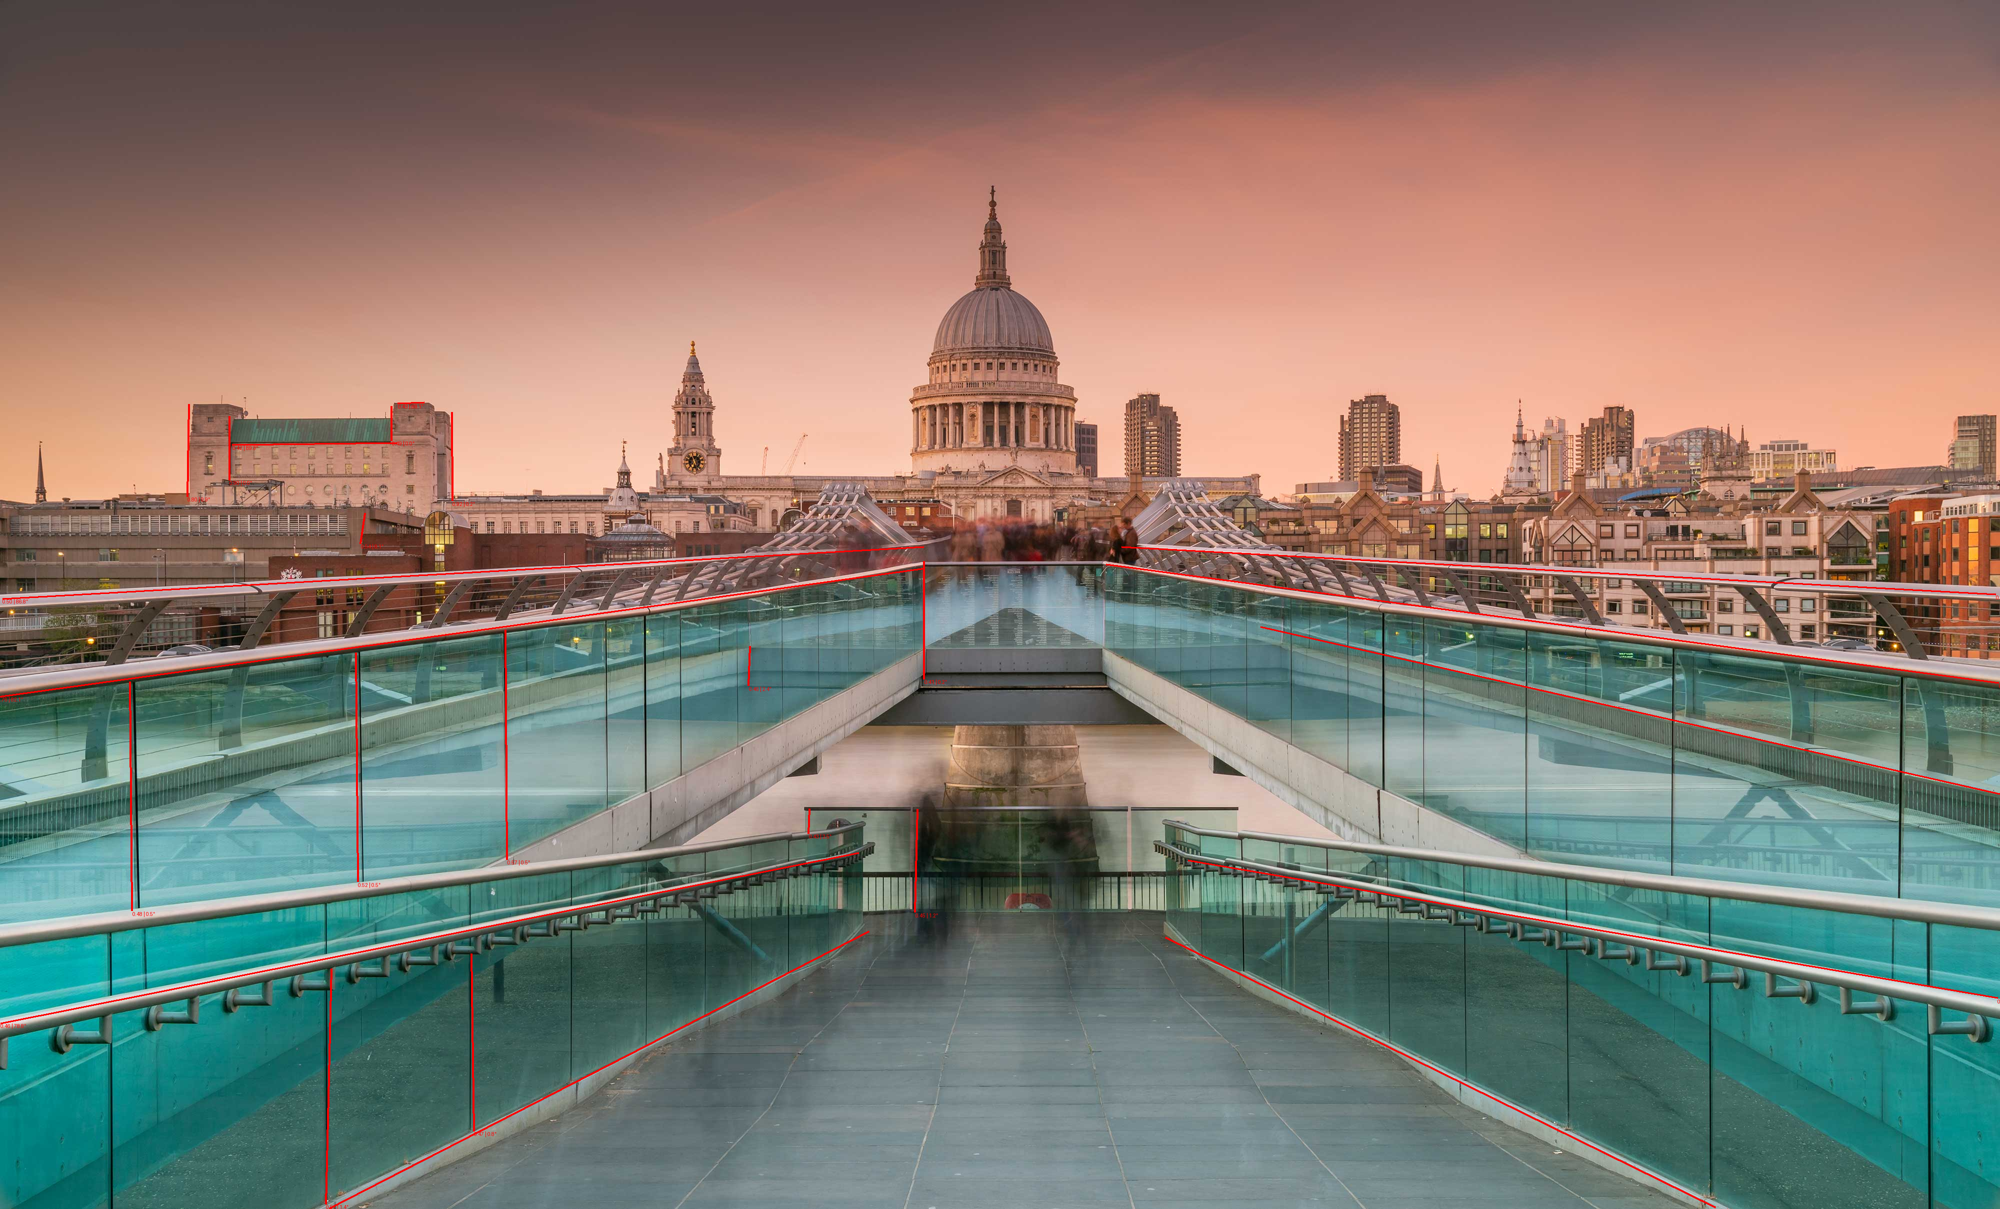

In [ ]:
PREVIEW_IMAGE = sorted(glob.glob(os.path.join(IMAGE_DIR, '*.jpg')) +
                       glob.glob(os.path.join(IMAGE_DIR, '*.png')))[0]

im_pil, w, h, lines, scores = infer(PREVIEW_IMAGE)
draw_im = im_pil.copy()
canvas  = ImageDraw.Draw(draw_im)

mask = scores > CONF_THRESHOLD
for line, score in zip(lines[mask].cpu().tolist(), scores[mask].cpu().tolist()):
    x1, y1, x2, y2 = line
    # color = 'red' if is_vertical(x1, y1, x2, y2) else 'red'
    color = 'red'
    canvas.line([(x1, y1), (x2, y2)], fill=color, width=4)
    canvas.text((x1, y1), f"{score:.2f} | {angle_from_y_axis(x1,y1,x2,y2):.1f}°", fill=color)

print(f'Preview: {os.path.basename(PREVIEW_IMAGE)}')
display(draw_im.resize((draw_im.width // 2, draw_im.height // 2)))

In [ ]:
image_paths = sorted(
    glob.glob(os.path.join(IMAGE_DIR, '*.jpg'))  +
    glob.glob(os.path.join(IMAGE_DIR, '*.jpeg')) +
    glob.glob(os.path.join(IMAGE_DIR, '*.png'))
)

assert image_paths, f'No images found in {IMAGE_DIR}'
print(f'Found {len(image_paths)} images')

root     = Element('annotations')
ver      = SubElement(root, 'version'); ver.text = '1.1'
meta     = SubElement(root, 'meta')
task_el  = SubElement(meta, 'task')
labels_el = SubElement(task_el, 'labels')
lbl      = SubElement(labels_el, 'label')
SubElement(lbl, 'name').text = 'vertical_line'
SubElement(lbl, 'type').text = 'polyline'

for img_id, img_path in enumerate(image_paths):
    im_pil, w, h, lines, scores = infer(img_path)

    mask   = scores > CONF_THRESHOLD
    lines  = lines[mask]
    scores = scores[mask]

    img_el = SubElement(root, 'image')
    img_el.set('id',     str(img_id))
    img_el.set('name',   os.path.basename(img_path))
    img_el.set('width',  str(w))
    img_el.set('height', str(h))

    # kept = 0
    for line, score in zip(lines.cpu().tolist(), scores.cpu().tolist()):
        x1, y1, x2, y2 = line
        # if not is_vertical(x1, y1, x2, y2):
        #     continue
        angle = angle_from_y_axis(x1, y1, x2, y2)
        poly  = SubElement(img_el, 'polyline')
        poly.set('label',        'vertical_line')
        poly.set('occluded',     '0')
        poly.set('points',       f'{x1:.2f},{y1:.2f};{x2:.2f},{y2:.2f}')
        poly.set('z_order',      '0')
        poly.set('conf',         f'{score:.4f}')
        poly.set('angle_from_y', f'{angle:.2f}')
        # kept += 1

    print(f'  [{img_id+1:>3}/{len(image_paths)}] {os.path.basename(img_path):40s} '
          f'{mask.sum().item():>3} detected')

tree = ElementTree(root)
indent(tree, space='  ')
tree.write(OUTPUT_XML, encoding='utf-8', xml_declaration=True)
print(f'\n✅ Saved → {OUTPUT_XML}')

Found 56 images
  [  1/56] gg_architecture_094ffe9a22fb863211de7386157fd9da6558a86e.jpg  25 detected
  [  2/56] gg_architecture_0f4c1ea3d29177bf2433aa7076331568f309cdd3.jpg  17 detected
  [  3/56] gg_architecture_1d46c1729120d28c61962c43b7244351f0694210.jpg 116 detected
  [  4/56] gg_architecture_229eeca76791ed22d61c7a7fd87f5774de188942.jpg  13 detected
  [  5/56] gg_architecture_2c35f23eaf15531f689958452d77eb07a7aac797.jpg   1 detected
  [  6/56] gg_architecture_4cd66cb1a2a695fc1c99c5518423fd6e065cf99f.jpg  10 detected
  [  7/56] gg_architecture_4ec1865d080f2be4a01cc04f9c531ad4e2d4cb8a.jpg  46 detected
  [  8/56] gg_architecture_5d4b31d5537fcf0ef589d2ae4c5323851b706ffe.jpg  38 detected
  [  9/56] gg_architecture_5f2af6740abe86c223ffa40c07104dfb2983a766.jpg  17 detected
  [ 10/56] gg_architecture_6e027ac25027f82125eb0bbd3f9d50c3e2abf47b.jpeg  62 detected
  [ 11/56] gg_architecture_81a17b105b03f23718f8edcdba48c1fd1796a8d4.jpg  16 detected
  [ 12/56] gg_architecture_84d65f2c901de576507e4

In [ ]:
import xml.etree.ElementTree as ET

tree   = ET.parse(OUTPUT_XML)
images = tree.findall('image')
lines  = tree.findall('.//polyline')

angles = [float(l.get('angle_from_y')) for l in lines]
confs  = [float(l.get('conf'))         for l in lines]

print(f'Total images annotated : {len(images)}')
print(f'Total lines   : {len(lines)}')
if angles:
    print(f'Avg angle from Y-axis  : {sum(angles)/len(angles):.2f}°')
    print(f'Avg confidence         : {sum(confs)/len(confs):.4f}')

Total images annotated : 56
Total lines   : 1832
Avg angle from Y-axis  : 35.00°
Avg confidence         : 0.6598
